In [1]:
import scipy
from pathlib import Path
import numpy as np
import pandas as pd
import trimesh
from pathlib import Path
from dataclasses import dataclass
import numpy as np

In [ ]:
# Code to generate a CSV overview of the dataset

DATASET_ROOT = Path("dropbox")
SUBFOLDERS = [
    "boxes", "labels", "models", "obbs", "ops", "part mesh indices", "syms"
]

rows = []

for category_path in DATASET_ROOT.iterdir():
    if not category_path.is_dir():
        continue
    category_name = category_path.name
    syms_folder = category_path / "syms"
    if not syms_folder.exists():
        continue

    for mat_file in syms_folder.glob("*.mat"):
        data = scipy.io.loadmat(mat_file)
        if "shapename" not in data:
            continue
        shape_name = str(data["shapename"].squeeze())
        row_name = f"{category_name}_{mat_file.stem}"
        row = {"shape": row_name}

        for sub in SUBFOLDERS:
            sub_path = category_path / sub
            if sub_path.exists():
                if sub == "models":
                    obj_file = sub_path / f"{shape_name}.obj"
                    row[sub] = str(obj_file) if obj_file.exists() else None
                elif sub == "obbs":
                    obb_file = sub_path / f"{shape_name}.obb"
                    row[sub] = str(obb_file) if obb_file.exists() else None
                else:
                    candidate = sub_path / mat_file.name
                    row[sub] = str(candidate) if candidate.exists() else None
            else:
                row[sub] = None

        rows.append(row)

df = pd.DataFrame(rows).set_index("shape").sort_index()
df.columns = [c.replace(" ", "_") for c in df.columns]
df.to_csv("dataset_overview.csv")
print("Saved to 'dataset_overview.csv'")

Saved to 'dataset_overview.csv'


In [2]:
# ShapeData class to load and store shape data

@dataclass
class ShapeData:
    boxes: np.ndarray = None
    labels: np.ndarray = None
    models: str = None
    obbs: str = None
    ops: np.ndarray = None
    part_mesh_indices: np.ndarray = None
    syms: np.ndarray = None
    shapename: str = None

    def __init__(self, row):
        """
        Initialize ShapeData from a DataFrame row like chair_1_row.
        `row` should contain columns: boxes, labels, models, obbs, ops,
        part mesh indices, syms
        """
        # Load .mat files as numpy arrays
        if row.boxes:       self.boxes = scipy.io.loadmat(row.boxes).get("box", None)
        if row.labels:      self.labels = scipy.io.loadmat(row.labels).get("label", None)
        if row.ops:         self.ops = scipy.io.loadmat(row.ops).get("op", None)
        if row.part_mesh_indices:
            self.part_mesh_indices = scipy.io.loadmat(row.part_mesh_indices).get("cell_boxs_correspond_objSerialNumber", None)
        if row.syms:
            sym_mat = scipy.io.loadmat(row.syms)
            self.syms = sym_mat.get("sym", None)
            self.shapename = str(sym_mat.get("shapename", None).squeeze())

        # Store paths to .obj and .obb
        self.models = row.models if row.models else None
        self.obbs = row.obbs if row.obbs else None

In [120]:
# Load CSV and get Chair_1 row
df = pd.read_csv("dataset_overview.csv", index_col="shape")
chair_row = df.loc["Chair_5200"]

In [ ]:
def display_section(description, data):
    print(f"\n=== {description} ===")
    if isinstance(data, (list, tuple, np.ndarray)):
        print(data)
    else:
        print(f"  {data}")

# Mapping folder names to human-readable descriptions
file_descriptions = {
    "boxes": "Part bounding boxes for leaf nodes",
    "labels": "Semantic labels for each leaf node",
    "models": "3D mesh model (.obj)",
    "obbs": "Oriented bounding boxes for the whole shape",
    "ops": "Node types of the symmetry hierarchy (0=leaf,1=adjacency,2=symmetry)",
    "part mesh indices": "Part mesh indices for leaf nodes",
    "syms": "Symmetry parameters for each symmetry node"
}

# Assuming chair_1_row is a row from your CSV
chair = ShapeData(chair_row)

display_section(file_descriptions["boxes"], chair.boxes)
display_section(file_descriptions["labels"], chair.labels)
display_section(file_descriptions["models"], chair.models)
display_section(file_descriptions["obbs"], chair.obbs)
display_section(file_descriptions["ops"], chair.ops)
display_section(file_descriptions["part mesh indices"], chair.part_mesh_indices)
display_section(file_descriptions["syms"], chair.syms)
display_section("Shape name", chair.shapename)

NameError: name 'ShapeData' is not defined

In [122]:
# Load the mesh
# mesh = trimesh.load(chair.models, force='mesh')
# Quick info
# print(mesh)  # Shows number of vertices, faces, etc.
# Visualize in a window
# mesh.show()

In [123]:
from enum import Enum


class Tree(object):
    class NodeType(Enum):
        BOX = 0  # box node
        ADJ = 1  # adjacency (adjacent part assembly) node
        SYM = 2  # symmetry (symmetric part grouping) node

    class Node(object):
        def __init__(self, box=None, left=None, right=None, node_type=None, sym=None, label=None):
            self.box = box          # box feature vector for a leaf node
            self.sym = sym          # symmetry parameter vector for a symmetry node
            self.left = left        # left child for ADJ or SYM (a symmeter generator)
            self.right = right      # right child
            self.node_type = node_type
            self.label = label

        def is_leaf(self):
            return self.node_type == Tree.NodeType.BOX and self.box is not None

        def is_adj(self):
            return self.node_type == Tree.NodeType.ADJ

        def is_sym(self):
            return self.node_type == Tree.NodeType.SYM

    def __init__(self, boxes, ops, syms, labels):
        box_list = [b for b in torch.split(boxes, 1, 0)]
        sym_param = [s for s in torch.split(syms, 1, 0)]
        label_list = [l for l in labels[0]]
        box_list.reverse()
        sym_param.reverse()
        label_list.reverse()
        queue = []
        for id in range(ops.size()[1]):
            if ops[0, id] == Tree.NodeType.BOX.value:
                queue.append(Tree.Node(box=box_list.pop(), node_type=Tree.NodeType.BOX, label=label_list.pop()))
            elif ops[0, id] == Tree.NodeType.ADJ.value:
                left_node = queue.pop()
                right_node = queue.pop()
                queue.append(Tree.Node(left=left_node, right=right_node, node_type=Tree.NodeType.ADJ))
            elif ops[0, id] == Tree.NodeType.SYM.value:
                node = queue.pop()
                queue.append(Tree.Node(left=node, sym=sym_param.pop(), node_type=Tree.NodeType.SYM))
        assert len(queue) == 1
        self.root = queue[0]

In [124]:
import torch

# Assuming these are numpy arrays from your display
boxes = torch.tensor(chair.boxes, dtype=torch.float).t()  # transpose like the GRASSDataset does
ops = torch.tensor(chair.ops, dtype=torch.int)
syms = torch.tensor(chair.syms, dtype=torch.float).t()    # transpose like GRASSDataset
labels = torch.tensor(chair.labels, dtype=torch.int)

# Build the tree
tree = Tree(boxes, ops, syms, labels)

In [125]:
# Map numeric labels to human-readable part names
label_names = {
    0: "Backrest",
    1: "Seat",
    2: "Leg",
    3: "Armrest"
}

def print_full_tree(node, prefix="", is_last=True):
    """
    Print a fully annotated tree with all parameters:
    - Leaf nodes: label, name, bounding box
    - Symmetry nodes: parameters
    - ADJ nodes: just indicate type
    """
    branch = "└─ " if is_last else "├─ "

    if node.is_leaf():
        part_name = label_names.get(node.label.item(), f"Unknown({node.label.item()})")
        box_values = node.box.squeeze().tolist()
        print(f"{prefix}{branch}Leaf: {part_name}, Label={node.label.item()}, Box={box_values}")
    elif node.is_adj():
        print(f"{prefix}{branch}Adjacency Node")
        children = [node.left, node.right]
        for i, child in enumerate(children):
            print_full_tree(child, prefix + ("    " if is_last else "│   "), i == len(children)-1)
    elif node.is_sym():
        sym_values = node.sym.squeeze().tolist()
        print(f"{prefix}{branch}Symmetry Node: Sym Params={sym_values}")
        print_full_tree(node.left, prefix + ("    " if is_last else "│   "), True)
    else:
        print(f"{prefix}{branch}Unknown Node Type")

# Print the full tree for your chair
print("Fully Annotated Chair Tree:")
print_full_tree(tree.root)

Fully Annotated Chair Tree:
└─ Adjacency Node
    ├─ Leaf: Backrest, Label=0, Box=[-0.004973500035703182, 0.3169879913330078, -0.170196995139122, 0.9380000233650208, 0.2381190061569214, 0.8227270245552063, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
    └─ Adjacency Node
        ├─ Adjacency Node
        │   ├─ Adjacency Node
        │   │   ├─ Adjacency Node
        │   │   │   ├─ Symmetry Node: Sym Params=[0.0, 0.9989479780197144, 0.011581899598240852, -0.04436270147562027, -0.004371929913759232, -0.3776409924030304, 0.39815598726272583, 0.0]
        │   │   │   │   └─ Adjacency Node
        │   │   │   │       ├─ Leaf: Leg, Label=2, Box=[-0.39765501022338867, -0.563086986541748, 0.1850609928369522, 0.06603900343179703, 0.6953129768371582, 0.03736099973320961, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
        │   │   │   │       └─ Leaf: Leg, Label=2, Box=[0.38365301489830017, -0.3731420040130615, 0.3809239864349365, 0.1258469969034195, 0.4687950015068054, 0.049556098878383636, 0.04770030081272125, 0.76828497

In [126]:
def print_obb_file(file_path):
    """
    Print the entire contents of a .obb file.
    """
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        print(content)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print_obb_file(chair.obbs)

N 19
-0.0049735 0.316988 -0.170197 1 0 0 0 1 0 0 0 1 0.822727 0.938 0.238119
-0.0107365 -0.569829 -0.198076 1 0 0 0 1 0 0 0 1 0.721121 0.045269 0.042293
-0.395827 -0.395841 0.185894 1 0 0 0 1 0 0 0 1 0.04102 0.31516 0.161034
-0.395321 -0.377668 -0.0223547 -0.00313899 -0.712782 -0.701379 0.997972 -0.046829 0.0431239 -0.0635828 -0.699821 0.711483 0.426656 0.0412595 0.071701
-0.393555 -0.415872 -0.0113315 -0.0166625 0.677465 -0.735366 0.999225 0.0375075 0.0119131 0.0356525 -0.734598 -0.677566 0.368856 0.0494843 0.127129
-0.397133 -0.334305 0.425165 0.110768 0.726711 -0.677954 0.993794 -0.0739816 0.0830702 0.0102119 -0.682948 -0.730396 0.0838066 0.042883 0.554555
-0.392397 -0.382139 0.415388 -0.00998412 -0.711728 -0.702385 0.99995 -0.00752882 -0.00658493 -0.000601445 -0.702415 0.711767 0.13945 0.0489603 0.482989
-0.397655 -0.563087 0.185061 1 0 0 0 1 0 0 0 1 0.037361 0.066039 0.695313
0.387769 -0.363629 0.190859 1 0 0 0 1 0 0 0 1 0.037239 0.276615 0.060188
0.383653 -0.373142 0.380924 -0.01

In [127]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from numpy import linalg as LA
import torch

def draw(ax, p, color):
    """Draws a single oriented bounding box on the given Axes3D object."""
    tmpPoint = p

    center = tmpPoint[0:3]
    lengths = tmpPoint[3:6]
    dir_1 = tmpPoint[6:9]
    dir_2 = tmpPoint[9:]

    dir_1 = dir_1 / LA.norm(dir_1)
    dir_2 = dir_2 / LA.norm(dir_2)
    dir_3 = np.cross(dir_1, dir_2)
    dir_3 = dir_3 / LA.norm(dir_3)

    d1 = 0.5 * lengths[0] * dir_1
    d2 = 0.5 * lengths[1] * dir_2
    d3 = 0.5 * lengths[2] * dir_3

    # Compute corner points
    cornerpoints = np.array([
        center - d1 - d2 - d3,
        center - d1 + d2 - d3,
        center + d1 - d2 - d3,
        center + d1 + d2 - d3,
        center - d1 - d2 + d3,
        center - d1 + d2 + d3,
        center + d1 - d2 + d3,
        center + d1 + d2 + d3
    ])

    edges = [
        [0,1],[0,2],[1,3],[2,3],
        [4,5],[4,6],[5,7],[6,7],
        [0,4],[1,5],[2,6],[3,7]
    ]
    for e in edges:
        ax.plot(
            [cornerpoints[e[0]][0], cornerpoints[e[1]][0]],
            [cornerpoints[e[0]][1], cornerpoints[e[1]][1]],
            [cornerpoints[e[0]][2], cornerpoints[e[1]][2]],
            c=color
        )

def showGenshape(genshape):
    """
    Plots a single set of oriented bounding boxes.
    
    genshape: list of torch.Tensor or numpy arrays, each of shape [1,12] or [12]
    """
    recover_boxes = genshape

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect([1,1,1])

    cmap = plt.get_cmap('jet_r')

    for jj, box in enumerate(recover_boxes):
        if isinstance(box, torch.Tensor):
            p = box.squeeze(0).numpy()
        else:
            p = box.squeeze()
        draw(ax, p, cmap(float(jj) / len(recover_boxes)))

    plt.show()

def plot_obb_from_file(file_path):
    """
    Reads an OBB file and plots the boxes using showGenshape().
    
    Args:
        file_path (str): Path to the OBB file.
    """
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines[0].startswith('N'):
        raise ValueError("File format error: first line must start with 'N'")
    num_boxes = int(lines[0].split()[1])
    
    obb_lines = lines[1:1+num_boxes]
    
    genshape = []
    for line in obb_lines:
        vals = np.array([float(x) for x in line.split()])
        if len(vals) == 15:
            # center(0:3), lengths(12:15), dir1(3:6), dir2(6:9)
            vals = np.concatenate([vals[0:3], vals[12:15], vals[3:6], vals[6:9]])
        elif len(vals) == 12:
            pass
        else:
            raise ValueError(f"Unexpected OBB length: {len(vals)}")
        genshape.append(torch.tensor(vals).unsqueeze(0))

    showGenshape(genshape)

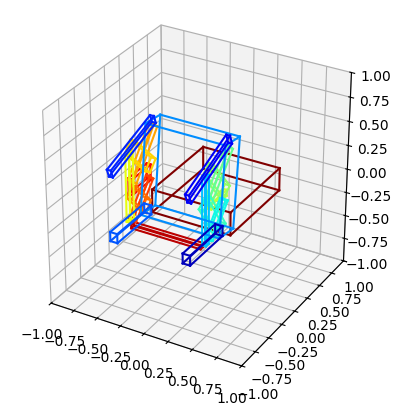

In [128]:
plot_obb_from_file(chair.obbs)

In [129]:
import numpy as np
import torch
import k3d

def obb_corners(box):
    """
    Compute the 8 corner points of a single OBB.
    
    box: numpy array of shape (12,) -> [center(3), lengths(3), dir1(3), dir2(3)]
    """
    center = box[0:3]
    lengths = box[3:6]
    dir1 = box[6:9] / np.linalg.norm(box[6:9])
    dir2 = box[9:12] / np.linalg.norm(box[9:12])
    dir3 = np.cross(dir1, dir2)
    dir3 /= np.linalg.norm(dir3)

    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3

    corners = np.array([
        center - d1 - d2 - d3,
        center - d1 + d2 - d3,
        center + d1 - d2 - d3,
        center + d1 + d2 - d3,
        center - d1 - d2 + d3,
        center - d1 + d2 + d3,
        center + d1 - d2 + d3,
        center + d1 + d2 + d3
    ])
    return corners

def plot_obb_from_file_k3d(file_path):
    """
    Read an OBB file and plot the corner points using K3D.
    """
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines[0].startswith('N'):
        raise ValueError("File format error: first line must start with 'N'")
    num_boxes = int(lines[0].split()[1])
    
    obb_lines = lines[1:1+num_boxes]
    
    obb_list = []
    for line in obb_lines:
        vals = np.array([float(x) for x in line.split()])
        if len(vals) == 15:
            # Convert to 12-element format [center(3), lengths(3), dir1(3), dir2(3)]
            vals = np.concatenate([vals[0:3], vals[12:15], vals[3:6], vals[6:9]])
        elif len(vals) == 12:
            pass
        else:
            raise ValueError(f"Unexpected OBB length: {len(vals)}")
        obb_list.append(torch.tensor(vals).unsqueeze(0))

    # Create K3D plot
    plot = k3d.plot()
    for box in obb_list:
        if isinstance(box, torch.Tensor):
            box = box.squeeze(0).numpy()
        corners = obb_corners(box)
        color = np.random.rand(3)  # random color per box
        k3d_color = int(color[0]*255)<<16 | int(color[1]*255)<<8 | int(color[2]*255)
        plot += k3d.points(corners.astype(np.float32), point_size=0.03, color=k3d_color)
    
    plot.display()

In [130]:
plot_obb_from_file_k3d(chair.obbs)

Output()

In [131]:
import numpy as np
import torch
import k3d

def obb_corners(box):
    """
    Compute the 8 corner points of a single OBB.
    
    box: numpy array of shape (12,) -> [center(3), lengths(3), dir1(3), dir2(3)]
    """
    center = box[0:3]
    lengths = box[3:6]
    dir1 = box[6:9] / np.linalg.norm(box[6:9])
    dir2 = box[9:12] / np.linalg.norm(box[9:12])
    dir3 = np.cross(dir1, dir2)
    dir3 /= np.linalg.norm(dir3)

    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3

    corners = np.array([
        center - d1 - d2 - d3,
        center - d1 + d2 - d3,
        center + d1 - d2 - d3,
        center + d1 + d2 - d3,
        center - d1 - d2 + d3,
        center - d1 + d2 + d3,
        center + d1 - d2 + d3,
        center + d1 + d2 + d3
    ])
    return corners

def draw_box_edges_k3d(corners, color):
    """
    Draw edges of a single box using K3D lines.
    
    corners: (8,3) array of corner points
    color: int, RGB encoded as 0xRRGGBB
    """
    # Define edges (pairs of corner indices)
    edges = [
        [0,1],[0,2],[1,3],[2,3],
        [4,5],[4,6],[5,7],[6,7],
        [0,4],[1,5],[2,6],[3,7]
    ]
    
    vertices = []
    for e in edges:
        vertices.append(corners[e[0]])
        vertices.append(corners[e[1]])
    vertices = np.array(vertices, dtype=np.float32)
    
    return k3d.line(vertices, shader='thick', width=0.01, color=color)

def plot_obb_edges_k3d(file_path):
    """
    Read an OBB file and plot the boxes as edges in K3D.
    """
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines[0].startswith('N'):
        raise ValueError("File format error: first line must start with 'N'")
    num_boxes = int(lines[0].split()[1])
    
    obb_lines = lines[1:1+num_boxes]
    
    obb_list = []
    for line in obb_lines:
        vals = np.array([float(x) for x in line.split()])
        if len(vals) == 15:
            vals = np.concatenate([vals[0:3], vals[12:15], vals[3:6], vals[6:9]])
        elif len(vals) == 12:
            pass
        else:
            raise ValueError(f"Unexpected OBB length: {len(vals)}")
        obb_list.append(torch.tensor(vals).unsqueeze(0))

    # K3D plot
    plot = k3d.plot()
    for box in obb_list:
        if isinstance(box, torch.Tensor):
            box = box.squeeze(0).numpy()
        corners = obb_corners(box)
        color = np.random.rand(3)  # random color
        k3d_color = int(color[0]*255)<<16 | int(color[1]*255)<<8 | int(color[2]*255)
        plot += draw_box_edges_k3d(corners, k3d_color)
    
    plot.display()

In [132]:
plot_obb_edges_k3d(chair.obbs)

Output()

In [134]:
def obb_to_k3d_mesh(center, lengths, dir1, dir2, color=0xff0000):
    import numpy as np
    import k3d

    dir1 = dir1 / np.linalg.norm(dir1)
    dir2 = dir2 / np.linalg.norm(dir2)
    dir3 = np.cross(dir1, dir2)
    dir3 /= np.linalg.norm(dir3)

    # 8 corners of the OBB
    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3

    corners = np.array([
        center - d1 - d2 - d3,
        center - d1 + d2 - d3,
        center + d1 - d2 - d3,
        center + d1 + d2 - d3,
        center - d1 - d2 + d3,
        center - d1 + d2 + d3,
        center + d1 - d2 + d3,
        center + d1 + d2 + d3
    ], dtype=np.float32)

    # Define faces using corner indices
    faces = np.array([
        [0,1,3], [0,3,2],  # bottom
        [4,6,7], [4,7,5],  # top
        [0,2,6], [0,6,4],  # front
        [1,5,7], [1,7,3],  # back
        [0,4,5], [0,5,1],  # left
        [2,3,7], [2,7,6]   # right
    ], dtype=np.uint32)

    return k3d.mesh(corners, faces, color=color)

In [135]:
import numpy as np
import torch
import k3d

def obb_to_mesh(box, color=0xff0000):
    """
    Convert a 12-element OBB vector to a K3D mesh (oriented cuboid).

    box: numpy array or torch tensor, shape [12] -> [center(3), lengths(3), dir1(3), dir2(3)]
    color: int, RGB color in 0xRRGGBB
    """
    if isinstance(box, torch.Tensor):
        box = box.squeeze(0).numpy()

    center = box[0:3]
    lengths = box[3:6]
    dir1 = box[6:9] / np.linalg.norm(box[6:9])
    dir2 = box[9:12] / np.linalg.norm(box[9:12])
    dir3 = np.cross(dir1, dir2)
    dir3 /= np.linalg.norm(dir3)

    # 8 corner points
    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3

    corners = np.array([
        center - d1 - d2 - d3,
        center - d1 + d2 - d3,
        center + d1 - d2 - d3,
        center + d1 + d2 - d3,
        center - d1 - d2 + d3,
        center - d1 + d2 + d3,
        center + d1 - d2 + d3,
        center + d1 + d2 + d3
    ], dtype=np.float32)

    # Triangles defining the cuboid faces
    faces = np.array([
        [0,1,3], [0,3,2],  # bottom
        [4,6,7], [4,7,5],  # top
        [0,2,6], [0,6,4],  # front
        [1,5,7], [1,7,3],  # back
        [0,4,5], [0,5,1],  # left
        [2,3,7], [2,7,6]   # right
    ], dtype=np.uint32)

    return k3d.mesh(corners, faces, color=color)

def plot_obb_file_mesh(file_path):
    """
    Reads an OBB file and plots all boxes as K3D cuboids (solid meshes).
    """
    with open(file_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines[0].startswith('N'):
        raise ValueError("File format error: first line must start with 'N'")
    num_boxes = int(lines[0].split()[1])
    obb_lines = lines[1:1+num_boxes]

    obb_list = []
    for line in obb_lines:
        vals = np.array([float(x) for x in line.split()])
        if len(vals) == 15:
            # Convert to 12-element format [center(3), lengths(3), dir1(3), dir2(3)]
            vals = np.concatenate([vals[0:3], vals[12:15], vals[3:6], vals[6:9]])
        elif len(vals) == 12:
            pass
        else:
            raise ValueError(f"Unexpected OBB length: {len(vals)}")
        obb_list.append(torch.tensor(vals).unsqueeze(0))

    # Create K3D plot
    plot = k3d.plot()
    for box in obb_list:
        color = np.random.rand(3)
        k3d_color = int(color[0]*255)<<16 | int(color[1]*255)<<8 | int(color[2]*255)
        plot += obb_to_mesh(box, color=k3d_color)

    plot.display()

In [136]:
plot_obb_file_mesh(chair.obbs)

Output()

In [ ]:
from __future__ import print_function, division
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg as LA
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

def parse_obb_file(obb_path):
    """
    Parse an .obb file with proper rotation matrix handling
    """
    data = {'boxes': [], 'connections': [], 'symmetries': [], 'labels': []}
    
    try:
        with open(obb_path, 'r') as f:
            content = f.read()
        lines = content.strip().split('\n')
    except:
        print(f"Error reading file: {obb_path}")
        return None
    
    current_section = None
    current_symmetry_group = None
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Check for section headers
        if line.startswith('N '):
            current_section = 'boxes'
            continue
        elif line.startswith('C '):
            current_section = 'connections'
            continue
        elif line.startswith('S '):
            current_section = 'symmetries'
            continue
        elif line.startswith('L '):
            current_section = 'labels'
            continue
        
        # Parse content
        if current_section == 'boxes':
            parts = list(map(float, line.split()))
            if len(parts) == 15:
                # Extract rotation matrix elements
                rot_elements = parts[3:12]
                
                # Create 3x3 rotation matrix
                rotation_matrix = np.array(rot_elements).reshape(3, 3)
                
                # FIX: Normalize the rotation matrix to ensure it's orthonormal
                rotation_matrix = normalize_rotation_matrix(rotation_matrix)
                
                box = {
                    'position': np.array(parts[0:3]),
                    'rotation': rotation_matrix,
                    'dimensions': np.array(parts[12:15])
                }
                data['boxes'].append(box)
        
        # ... rest of your parser remains the same
        
    return data

def draw_obb(ax, box_data, color='blue', alpha=0.6):
    """Draw a single oriented bounding box."""
    center = box_data['position']
    lengths = box_data['dimensions']
    rotation = box_data['rotation']
    
    # Get the three orthogonal directions from rotation matrix
    dir1 = rotation[:, 0]
    dir2 = rotation[:, 1]
    dir3 = np.cross(dir1, dir2)
    
    # Normalize directions
    dir1 = dir1 / LA.norm(dir1)
    dir2 = dir2 / LA.norm(dir2)
    dir3 = dir3 / LA.norm(dir3)
    
    # Compute corner points
    d1 = 0.5 * lengths[0] * dir1
    d2 = 0.5 * lengths[1] * dir2
    d3 = 0.5 * lengths[2] * dir3
    
    corners = np.array([
        center - d1 - d2 - d3,  # 0
        center - d1 + d2 - d3,  # 1
        center + d1 - d2 - d3,  # 2
        center + d1 + d2 - d3,  # 3
        center - d1 - d2 + d3,  # 4
        center - d1 + d2 + d3,  # 5
        center + d1 - d2 + d3,  # 6
        center + d1 + d2 + d3   # 7
    ])
    
    # Define edges
    edges = [
        (0,1), (0,2), (1,3), (2,3),  # bottom
        (4,5), (4,6), (5,7), (6,7),  # top
        (0,4), (1,5), (2,6), (3,7)   # sides
    ]
    
    # Draw edges
    for edge in edges:
        i, j = edge
        ax.plot([corners[i,0], corners[j,0]], 
                [corners[i,1], corners[j,1]], 
                [corners[i,2], corners[j,2]], 
                color=color, linewidth=2)
    
    # Draw transparent faces
    from matplotlib.colors import to_rgba
    face_color = to_rgba(color, alpha=alpha*0.3)
    
    # Bottom face
    bottom_verts = [corners[0], corners[1], corners[3], corners[2]]
    bottom_poly = plt.Polygon([(v[0], v[1]) for v in bottom_verts], color=face_color)
    ax.add_patch(bottom_poly)
    art3d.pathpatch_2d_to_3d(bottom_poly, z=corners[0,2], zdir="z")
    
    # Top face
    top_verts = [corners[4], corners[5], corners[7], corners[6]]
    top_poly = plt.Polygon([(v[0], v[1]) for v in top_verts], color=face_color)
    ax.add_patch(top_poly)
    art3d.pathpatch_2d_to_3d(top_poly, z=corners[4,2], zdir="z")

def visualize_parsed_obbs(parsed_data, title="Chair OBB Visualization"):
    """Visualize all OBBs from parsed data."""
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Color mapping for different part types
    color_map = {0: 'red', 1: 'green', 2: 'blue'}  # Backrest, Seat, Leg
    label_names = {0: 'Backrest', 1: 'Seat', 2: 'Leg'}
    
    # Draw each OBB with appropriate color
    for i, box in enumerate(parsed_data['boxes']):
        if i < len(parsed_data['labels']):
            label = parsed_data['labels'][i]
            color = color_map.get(label, 'gray')
            part_name = label_names.get(label, 'Unknown')
        else:
            color = 'gray'
            part_name = 'Unknown'
        
        draw_obb(ax, box, color=color)
        
        # Add label text
        ax.text(box['position'][0], box['position'][1], box['position'][2], 
                f'Box {i}\n({part_name})', fontsize=8, ha='center')
    
    # Draw connections
    for src, dst in parsed_data['connections']:
        if src < len(parsed_data['boxes']) and dst < len(parsed_data['boxes']):
            pos1 = parsed_data['boxes'][src]['position']
            pos2 = parsed_data['boxes'][dst]['position']
            ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], [pos1[2], pos2[2]], 
                   'k--', linewidth=1, alpha=0.5)
    
    # Set axis properties
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    # Set equal aspect ratio
    all_positions = np.array([box['position'] for box in parsed_data['boxes']])
    max_range = np.max(np.ptp(all_positions, axis=0)) * 1.2
    mid_x, mid_y, mid_z = np.mean(all_positions, axis=0)
    
    ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
    ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[i], label=label_names[i]) 
                      for i in color_map]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

def print_parsed_info(parsed_data):
    """Print information about the parsed OBB data."""
    print("=== PARSED OBB INFORMATION ===")
    print(f"Total boxes: {len(parsed_data['boxes'])}")
    print(f"Total connections: {len(parsed_data['connections'])}")
    print(f"Total symmetry groups: {len(parsed_data['symmetries'])}")
    print(f"Total labels: {len(parsed_data['labels'])}")
    
    print("\n--- Box Details ---")
    label_names = {0: 'Backrest', 1: 'Seat', 2: 'Leg'}
    for i, box in enumerate(parsed_data['boxes']):
        label = parsed_data['labels'][i] if i < len(parsed_data['labels']) else -1
        part_name = label_names.get(label, 'Unknown')
        print(f"Box {i}: {part_name} at {box['position']}, size {box['dimensions']}")
    
    print("\n--- Connections ---")
    for i, (src, dst) in enumerate(parsed_data['connections']):
        print(f"Connection {i}: Box {src} ↔ Box {dst}")
    
    print("\n--- Symmetry Groups ---")
    for i, group in enumerate(parsed_data['symmetries']):
        print(f"Group {i}: {group['num_boxes']} boxes")
        for box_info in group['boxes']:
            print(f"  Box {box_info['index']} at {box_info['position']}")

=== PARSED OBB INFORMATION ===
Total boxes: 3
Total connections: 0
Total symmetry groups: 0
Total labels: 0

--- Box Details ---
Box 0: Unknown at [ 0.0302842  0.488309  -0.315397 ], size [0.89214  0.305279 0.781198]
Box 1: Unknown at [ 0.00419755 -0.422335    0.169623  ], size [0.898086 0.523685 1.15351 ]
Box 2: Unknown at [0.0030865 0.148677  0.0724135], size [0.890567 0.223845 0.805681]

--- Connections ---

--- Symmetry Groups ---

Generating 3D visualization...


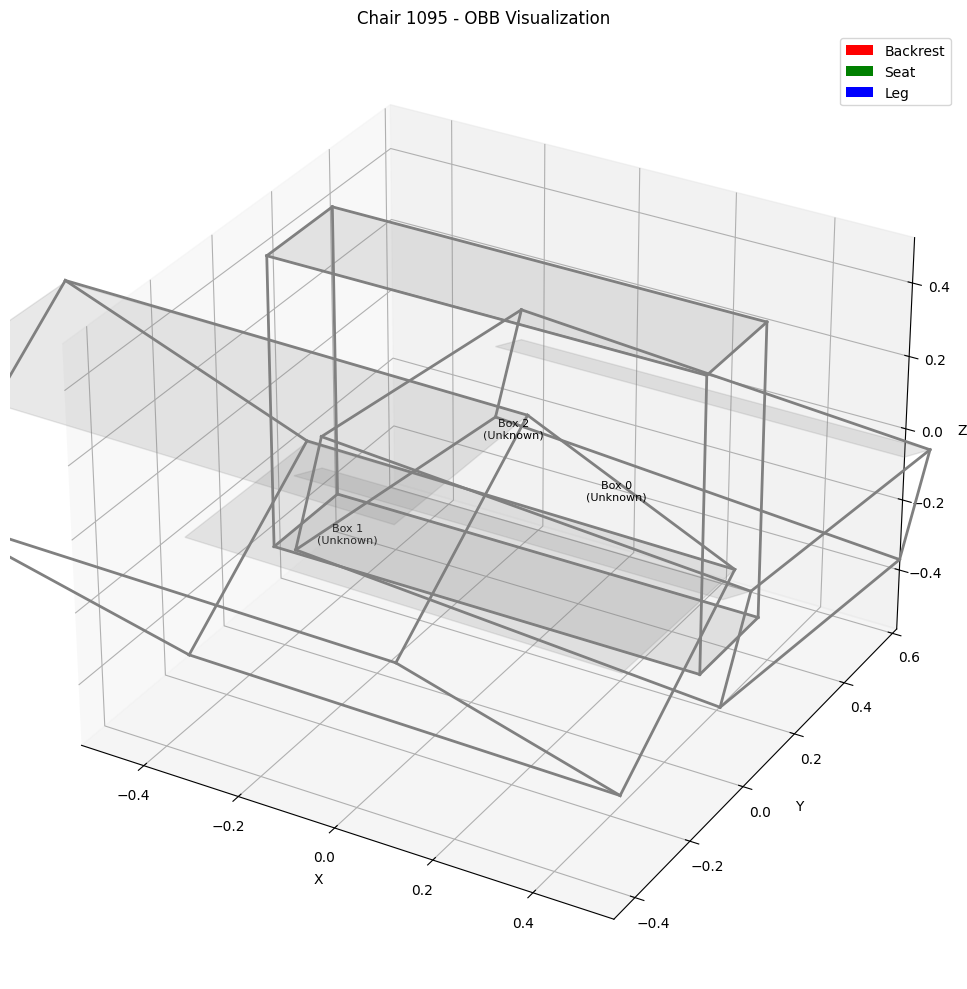

Visualization complete! Close the plot window to exit.


In [11]:
# Parse the OBB file
parsed_data = parse_obb_file(chair.obbs)

if parsed_data:
    # Print information
    print_parsed_info(parsed_data)
    
    # Visualize in 3D
    print("\nGenerating 3D visualization...")
    import matplotlib.patches as mpatches
    from mpl_toolkits.mplot3d import art3d
    
    fig, ax = visualize_parsed_obbs(parsed_data, "Chair {} - OBB Visualization".format(chair.shapename))
    
    print("Visualization complete! Close the plot window to exit.")
else:
    print("Failed to parse OBB file.")

In [133]:
mesh = trimesh.load(chair.models, force='mesh')
# Quick info
print(mesh)  # Shows number of vertices, faces, etc.
# Visualize in a window
mesh.show()

<trimesh.Trimesh(vertices.shape=(17722, 3), faces.shape=(35502, 3))>


In [13]:
def print_obb_file(file_path):
    """
    Print the entire contents of a .obb file.
    """
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        print(content)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print_obb_file(chair.obbs)

N 3
0.0302842 0.488309 -0.315397 -0.995024 0.0971271 -0.0222212 -0.00601635 0.164046 0.986434 0.0994548 0.981659 -0.162646 0.89214 0.305279 0.781198
0.00419755 -0.422335 0.169623 0.999916 0.0121707 -0.00438424 -0.0121707 0.770206 -0.637679 -0.00438424 0.637679 0.77029 0.898086 0.523685 1.15351
0.0030865 0.148677 0.0724135 1 0 0 0 1 0 0 0 1 0.890567 0.223845 0.805681
C 2
0 2
1 2
S 0
L 3
0
2
1


In [15]:
from __future__ import print_function, division
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg as LA
from mpl_toolkits.mplot3d import Axes3D

def parse_obb_file(filename):
    with open(filename, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    assert lines[0].startswith("N")
    n_nodes = int(lines[0].split()[1])

    # Parse node OBBs
    obbs = []
    for i in range(1, 1 + n_nodes):
        vals = list(map(float, lines[i].split()))
        center = vals[0:3]
        R = np.array(vals[3:12]).reshape(3, 3).T  # orientation
        half_sizes = vals[12:15]

        # Repackage into your "draw" format
        obb = center + half_sizes.tolist() + R[:,0].tolist() + R[:,1].tolist()
        obbs.append(obb)

    # Find where connections start
    conn_idx = 1 + n_nodes
    assert lines[conn_idx].startswith("C")
    n_conns = int(lines[conn_idx].split()[1])

    connections = []
    for i in range(conn_idx+1, conn_idx+1+n_conns):
        a, b = map(int, lines[i].split())
        connections.append((a, b))

    return obbs, connections

def draw(ax, p, color):
    center = np.array(p[0:3])
    lengths = np.array(p[3:6])
    dir_1 = np.array(p[6:9]); dir_1 /= LA.norm(dir_1)
    dir_2 = np.array(p[9:12]); dir_2 /= LA.norm(dir_2)
    dir_3 = np.cross(dir_1, dir_2); dir_3 /= LA.norm(dir_3)

    cornerpoints = np.zeros([8, 3])
    d1 = 0.5*lengths[0]*dir_1
    d2 = 0.5*lengths[1]*dir_2
    d3 = 0.5*lengths[2]*dir_3

    cornerpoints[0] = center - d1 - d2 - d3
    cornerpoints[1] = center - d1 + d2 - d3
    cornerpoints[2] = center + d1 - d2 - d3
    cornerpoints[3] = center + d1 + d2 - d3
    cornerpoints[4] = center - d1 - d2 + d3
    cornerpoints[5] = center - d1 + d2 + d3
    cornerpoints[6] = center + d1 - d2 + d3
    cornerpoints[7] = center + d1 + d2 + d3

    # box edges
    edges = [(0,1),(0,2),(1,3),(2,3),
             (4,5),(4,6),(5,7),(6,7),
             (0,4),(1,5),(2,6),(3,7)]
    for (i,j) in edges:
        ax.plot([cornerpoints[i,0], cornerpoints[j,0]],
                [cornerpoints[i,1], cornerpoints[j,1]],
                [cornerpoints[i,2], cornerpoints[j,2]], c=color)

    return center

def show_chair(obbs, connections):
    fig = plt.figure()
    ax = Axes3D(fig)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)

    cmap = plt.get_cmap("jet_r")

    centers = []
    for jj, p in enumerate(obbs):
        color = cmap(float(jj)/len(obbs))
        center = draw(ax, p, color)
        centers.append(center)

    # plot connections as lines between OBB centers
    for a, b in connections:
        ax.plot([centers[a][0], centers[b][0]],
                [centers[a][1], centers[b][1]],
                [centers[a][2], centers[b][2]], c="black", linewidth=2)

    plt.show()


obbs, connections = parse_obb_file(chair.obbs)  # put your filename here
show_chair(obbs, connections)

AttributeError: 'list' object has no attribute 'tolist'

In [16]:
chair.obbs

'dropbox/Chair/obbs/1095.obb'

In [17]:
def parse_and_print_obb(file_path):
    """
    Parse and print a .obb file in a human-readable format.
    """
    try:
        with open(file_path, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        print(f"📦 Parsing OBB File: {file_path}\n")

        # ---- Nodes ----
        assert lines[0].startswith("N")
        n_nodes = int(lines[0].split()[1])
        print(f"Number of Nodes: {n_nodes}\n")

        nodes = []
        for i in range(1, 1 + n_nodes):
            vals = list(map(float, lines[i].split()))
            center = vals[0:3]
            R = vals[3:12]       # rotation matrix (flattened)
            half_sizes = vals[12:15]
            nodes.append((center, R, half_sizes))

            print(f"Node {i-1}:")
            print(f"  Center     = {center}")
            print(f"  Half sizes = {half_sizes}")
            print(f"  Rotation   = {R}")
            print("")

        # ---- Connections ----
        conn_idx = 1 + n_nodes
        if lines[conn_idx].startswith("C"):
            n_conns = int(lines[conn_idx].split()[1])
            print(f"Connections ({n_conns}):")
            connections = []
            for j in range(conn_idx+1, conn_idx+1+n_conns):
                a, b = map(int, lines[j].split())
                connections.append((a, b))
                print(f"  Node {a} ↔ Node {b}")
            print("")

        # ---- Symmetry ----
        sym_idx = conn_idx + 1 + n_conns
        if lines[sym_idx].startswith("S"):
            n_syms = int(lines[sym_idx].split()[1])
            print(f"Symmetry groups: {n_syms}\n")

        # ---- Labels ----
        label_idx = [i for i, l in enumerate(lines) if l.startswith("L")][0]
        n_labels = int(lines[label_idx].split()[1])
        labels = [int(lines[label_idx+1+i]) for i in range(n_labels)]
        print(f"Labels ({n_labels}): {labels}")

    except Exception as e:
        print(f"❌ Error reading {file_path}: {e}")


# Example usage:
parse_and_print_obb("dropbox/Chair/obbs/1095.obb")

📦 Parsing OBB File: dropbox/Chair/obbs/1095.obb

Number of Nodes: 3

Node 0:
  Center     = [0.0302842, 0.488309, -0.315397]
  Half sizes = [0.89214, 0.305279, 0.781198]
  Rotation   = [-0.995024, 0.0971271, -0.0222212, -0.00601635, 0.164046, 0.986434, 0.0994548, 0.981659, -0.162646]

Node 1:
  Center     = [0.00419755, -0.422335, 0.169623]
  Half sizes = [0.898086, 0.523685, 1.15351]
  Rotation   = [0.999916, 0.0121707, -0.00438424, -0.0121707, 0.770206, -0.637679, -0.00438424, 0.637679, 0.77029]

Node 2:
  Center     = [0.0030865, 0.148677, 0.0724135]
  Half sizes = [0.890567, 0.223845, 0.805681]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Connections (2):
  Node 0 ↔ Node 2
  Node 1 ↔ Node 2

Symmetry groups: 0

Labels (3): [0, 2, 1]


📦 Parsing OBB File: dropbox/Chair/obbs/257.obb

Number of Nodes: 6

Node 0:
  Center     = [0.005689, 0.392495, -0.245461]
  Half sizes = [0.88481, 0.879493, 0.3045]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Node 1:
  Center     = [0.005689, -0.115248, 0.107792]
  Half sizes = [0.88481, 0.204901, 1.01101]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Node 2:
  Center     = [-0.359589, -0.452346, -0.299559]
  Half sizes = [0.154254, 0.541163, 0.196303]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Node 3:
  Center     = [0.380772, -0.4528, -0.296922]
  Half sizes = [0.134644, 0.540255, 0.201577]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Node 4:
  Center     = [0.371263, -0.451533, 0.519062]
  Half sizes = [0.153662, 0.54279, 0.188467]
  Rotation   = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]

Node 5:
  Center     = [-0.333896, -0.44475, 0.519707]
  Half sizes = [0.205641, 0.556357, 0.187177]
  Rotation   = [1.0, 

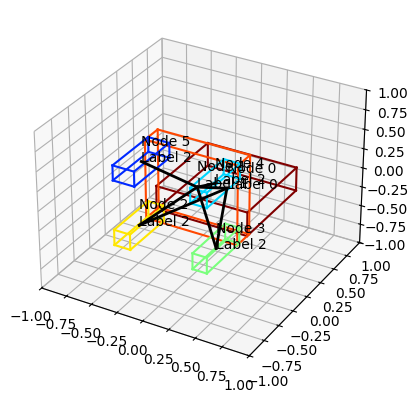

In [21]:
from matplotlib import pyplot as plt
import numpy as np
from numpy import linalg as LA
from mpl_toolkits.mplot3d import Axes3D

def parse_and_print_obb(file_path):
    """
    Parse a .obb file and print a human-readable summary.
    Returns: nodes (list of [center, R, half_sizes]), connections, labels
    """
    try:
        with open(file_path, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        print(f"📦 Parsing OBB File: {file_path}\n")

        # ---- Nodes ----
        assert lines[0].startswith("N")
        n_nodes = int(lines[0].split()[1])
        print(f"Number of Nodes: {n_nodes}\n")

        nodes = []
        for i in range(1, 1 + n_nodes):
            vals = list(map(float, lines[i].split()))
            center = vals[0:3]
            R = np.array(vals[3:12]).reshape(3, 3).T
            half_sizes = vals[12:15]
            nodes.append((center, R, half_sizes))

            print(f"Node {i-1}:")
            print(f"  Center     = {center}")
            print(f"  Half sizes = {half_sizes}")
            print(f"  Rotation   = {R.flatten().tolist()}")
            print("")

        # ---- Connections ----
        conn_idx = 1 + n_nodes
        connections = []
        if lines[conn_idx].startswith("C"):
            n_conns = int(lines[conn_idx].split()[1])
            print(f"Connections ({n_conns}):")
            for j in range(conn_idx+1, conn_idx+1+n_conns):
                a, b = map(int, lines[j].split())
                connections.append((a, b))
                print(f"  Node {a} ↔ Node {b}")
            print("")

        # ---- Symmetry ----
        sym_idx = conn_idx + 1 + len(connections)
        if lines[sym_idx].startswith("S"):
            n_syms = int(lines[sym_idx].split()[1])
            print(f"Symmetry groups: {n_syms}\n")

        # ---- Labels ----
        label_idx = [i for i, l in enumerate(lines) if l.startswith("L")][0]
        n_labels = int(lines[label_idx].split()[1])
        labels = [int(lines[label_idx+1+i]) for i in range(n_labels)]
        print(f"Labels ({n_labels}): {labels}")

        return nodes, connections, labels

    except Exception as e:
        print(f"❌ Error reading {file_path}: {e}")
        return [], [], []


def draw_box(ax, center, R, half_sizes, color):
    """
    Draw a single oriented bounding box.
    """
    dir_1 = R[:,0] / LA.norm(R[:,0])
    dir_2 = R[:,1] / LA.norm(R[:,1])
    dir_3 = np.cross(dir_1, dir_2); dir_3 /= LA.norm(dir_3)

    d1 = 0.5 * half_sizes[0] * dir_1
    d2 = 0.5 * half_sizes[1] * dir_2
    d3 = 0.5 * half_sizes[2] * dir_3

    # 8 corners
    corners = np.zeros((8,3))
    corners[0] = center - d1 - d2 - d3
    corners[1] = center - d1 + d2 - d3
    corners[2] = center + d1 - d2 - d3
    corners[3] = center + d1 + d2 - d3
    corners[4] = center - d1 - d2 + d3
    corners[5] = center - d1 + d2 + d3
    corners[6] = center + d1 - d2 + d3
    corners[7] = center + d1 + d2 + d3

    edges = [(0,1),(0,2),(1,3),(2,3),
             (4,5),(4,6),(5,7),(6,7),
             (0,4),(1,5),(2,6),(3,7)]

    for (i,j) in edges:
        ax.plot([corners[i,0], corners[j,0]],
                [corners[i,1], corners[j,1]],
                [corners[i,2], corners[j,2]], c=color)


def plot_obb_structure(nodes, connections, labels):
    """
    Plot all nodes and their connections.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")  # <-- modern way
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)

    cmap = plt.get_cmap("jet_r")
    centers = []

    for jj, (center, R, half_sizes) in enumerate(nodes):
        color = cmap(float(jj)/len(nodes))
        draw_box(ax, np.array(center), R, np.array(half_sizes), color)
        centers.append(center)
        ax.text(center[0], center[1], center[2],
                f"Node {jj}\nLabel {labels[jj]}",
                color="black")

    # connections as black lines
    for a, b in connections:
        ax.plot([centers[a][0], centers[b][0]],
                [centers[a][1], centers[b][1]],
                [centers[a][2], centers[b][2]],
                c="black", linewidth=2)

    plt.show()


if __name__ == "__main__":
    file_path = "dropbox/Chair/obbs/257.obb"
    nodes, connections, labels = parse_and_print_obb(file_path)
    plot_obb_structure(nodes, connections, labels)